In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
import shap


In [ ]:
df = pd.read_csv("ashrae_db2.01.csv", engine='python')

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (35413, 70)
                              Publication (Citation) Data contributor  Year  \
0  Kwok, Alison G., and Chungyoon Chun. "Thermal ...      Kwok Alison  2000   
1  Kwok, Alison G., and Chungyoon Chun. "Thermal ...      Kwok Alison  2000   
2  Kwok, Alison G., and Chungyoon Chun. "Thermal ...      Kwok Alison  2000   
3  Kwok, Alison G., and Chungyoon Chun. "Thermal ...      Kwok Alison  2000   
4  Kwok, Alison G., and Chungyoon Chun. "Thermal ...      Kwok Alison  2000   

   Season Koppen climate classification            Climate   City Country  \
0  Summer                           Cfa  Humid subtropical  Tokyo   Japan   
1  Summer                           Cfa  Humid subtropical  Tokyo   Japan   
2  Summer                           Cfa  Humid subtropical  Tokyo   Japan   
3  Summer                           Cfa  Humid subtropical  Tokyo   Japan   
4  Summer                           Cfa  Humid subtropical  Tokyo   Japan   

  Building type Cooling startegy_bu

In [ ]:
df = df[['Air temperature (C)',
         'Relative humidity (%)',
         'Air velocity (m/s)',
         'Met',
         'Clo',
         'Thermal sensation']]

df = df.dropna()
print("After cleaning:", df.shape)

After cleaning: (23150, 6)


In [ ]:
df.columns = ['ta', 'rh', 'v', 'met', 'clo', 'thermal_sensation']

In [ ]:
df['comfort_binary'] = df['thermal_sensation'].apply(lambda x: 1 if x >= 0 else 0)

In [ ]:
print("\nDescriptive Statistics:")
print(df.describe())


Descriptive Statistics:
                 ta            rh             v           met           clo  \
count  23150.000000  23150.000000  23150.000000  23150.000000  23150.000000   
mean      25.051179     47.013305      0.185746      1.163778      0.673835   
std        4.030406     14.423813      0.569135      0.220989      0.282894   
min        0.600000     10.300000      0.000000      0.700000      0.030000   
25%       22.000000     36.000000      0.050000      1.000000      0.500000   
50%       25.100000     45.600000      0.100000      1.100000      0.670000   
75%       28.000000     57.200000      0.230000      1.200000      0.750000   
max       45.200000     95.300000     56.170000      3.800000      2.770000   

       thermal_sensation  comfort_binary  
count       23150.000000    23150.000000  
mean            0.087957        0.700648  
std             1.309138        0.457984  
min            -3.000000        0.000000  
25%            -1.000000        0.000000  
50%  

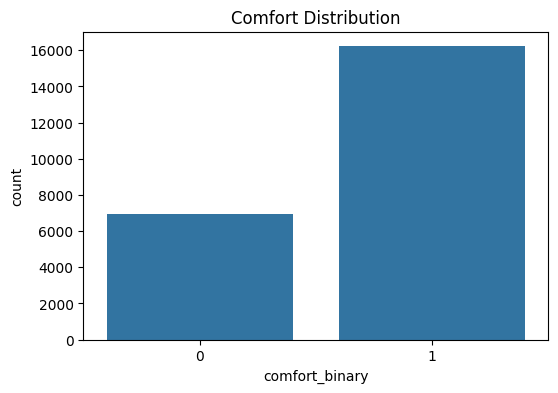

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='comfort_binary', data=df)
plt.title("Comfort Distribution")
plt.show()

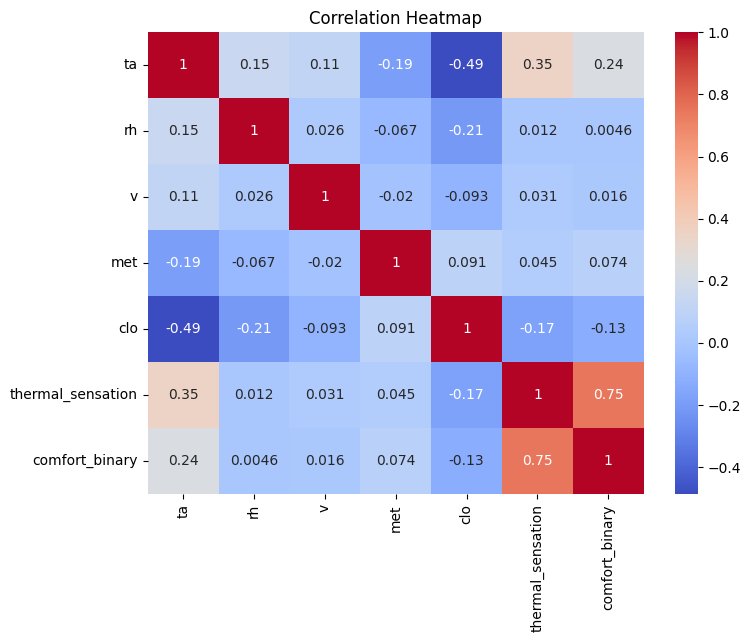

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

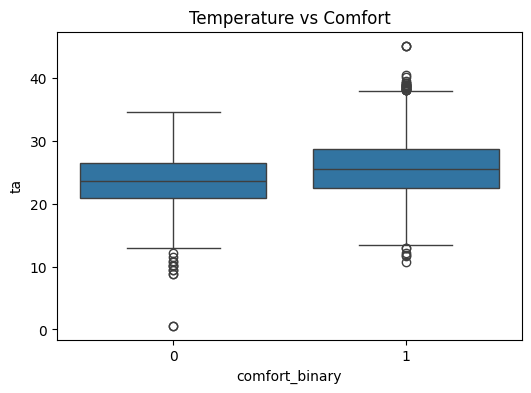

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x='comfort_binary', y='ta', data=df)
plt.title("Temperature vs Comfort")
plt.show()

In [ ]:
df['THI'] = df['ta'] - (0.55 - 0.0055 * df['rh']) * (df['ta'] - 14.5)

In [ ]:
X = df[['ta', 'rh', 'v', 'met', 'clo', 'THI']]
y = df['comfort_binary']

In [ ]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:36:58] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
models = {"Logistic Regression": lr, "Random Forest": rf, "XGBoost": xgb}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))


Logistic Regression
Accuracy: 0.6217632552404438
              precision    recall  f1-score   support

           0       0.60      0.67      0.63      3168
           1       0.65      0.58      0.61      3320

    accuracy                           0.62      6488
   macro avg       0.62      0.62      0.62      6488
weighted avg       0.62      0.62      0.62      6488


Random Forest
Accuracy: 0.7967016029593095
              precision    recall  f1-score   support

           0       0.79      0.80      0.79      3168
           1       0.81      0.79      0.80      3320

    accuracy                           0.80      6488
   macro avg       0.80      0.80      0.80      6488
weighted avg       0.80      0.80      0.80      6488


XGBoost
Accuracy: 0.7848335388409371
              precision    recall  f1-score   support

           0       0.78      0.78      0.78      3168
           1       0.79      0.79      0.79      3320

    accuracy                           0.78      6

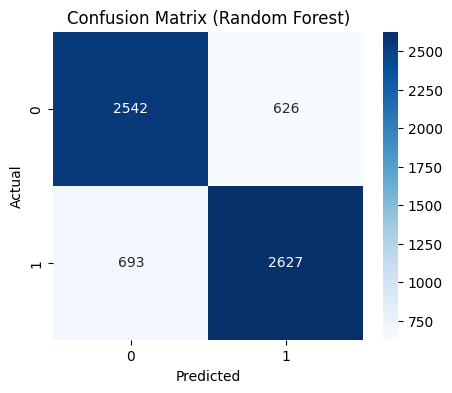

In [ ]:
cm = confusion_matrix(y_test, rf.predict(X_test))

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

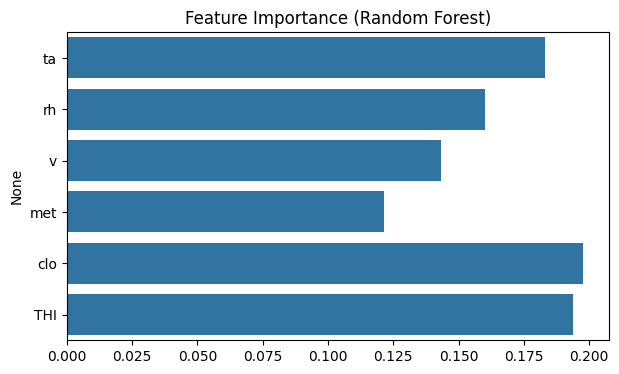

In [ ]:
feature_names = X.columns
importances = rf.feature_importances_

plt.figure(figsize=(7,4))
sns.barplot(x=importances, y=feature_names)
plt.title("Feature Importance (Random Forest)")
plt.show()


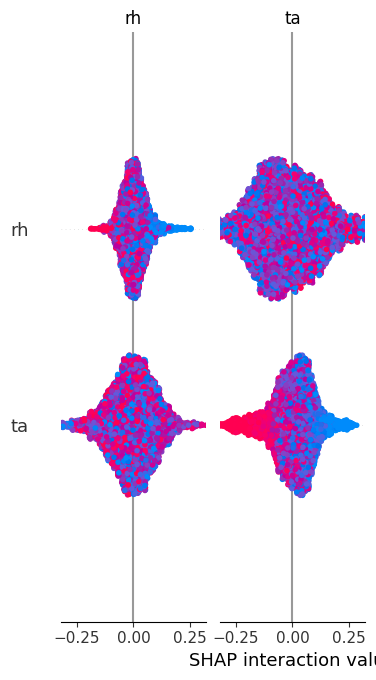

In [ ]:

explainer = shap.Explainer(rf)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test, feature_names=feature_names)